[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mlexchange/als_ml_tutorial/blob/main/3_4_ML_tutorial_CNN.ipynb)

# 1. Pretrain an encoder to convert images to latent vectors
## Set environment and load model

In [1]:
import torch

import mlflow
from mlflow.models import infer_signature

device = torch.device("cuda:1") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

Device: cuda:1


In [2]:
#from torchsummary import summary
from model_utils import cnnAutoencoder

auto_cnn = cnnAutoencoder(input_shape=(3, 128, 128), latent_dim=1000)
auto_cnn.to(device)

print(auto_cnn)

cnnAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=65536, out_features=1000, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=1000, out_features=65536, bias=True)
    (1): Unflatten(dim=1, unflattened_size=(64, 32, 32))
    (2): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  )
)


## Data Preparation



In [3]:
import model_utils
from torch.utils.data import DataLoader, random_split
from torchvision import transforms


data_directory = '/lovelace/xiaoya/GenAI_dataset/dynamic_latent/trainset/'
input_size = 128
data_transform=transforms.Compose([transforms.Resize(input_size),
                              transforms.CenterCrop(input_size),
                              transforms.ToTensor(),
                              transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
                             ])
dataset = model_utils.myDataset(data_directory, transform=data_transform)

# Split the dataset into training and validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
print(len(train_loader), len(val_loader))

10 3


In [4]:
print(val_size)

40


## Training the encoder

In [5]:
from torch.nn import MSELoss
from torch.optim import AdamW
from tqdm import tqdm

# Training parameters
criterion = MSELoss()
optimizer = AdamW(auto_cnn.parameters(), lr=0.001)   #0.005
num_epochs = 100     #20

epoch_loss = []
epoch_val_loss = []
for epoch in range(num_epochs):
    auto_cnn.train()                        # Set the model to training mode
    for input_batch, labels in tqdm(train_loader):
        optimizer.zero_grad()               # Zero the gradients
        out_batch = auto_cnn(input_batch.to(device))          # Forward pass
        loss = criterion(out_batch, input_batch.to(device))   # Compute loss
        loss.backward()                     # Backpropagation
        optimizer.step()                    # Update weights
    # auto_cnn.eval()
    val_loss = 0.0
    with torch.no_grad():                   # Validation
        for val_batch, labels in tqdm(val_loader):
            out_val_batch = auto_cnn(val_batch.to(device))
            val_batch_loss = criterion(out_val_batch, val_batch.to(device))
            val_loss += val_batch_loss.item()
    avg_val_loss = val_loss / len(val_loader)
    epoch_loss.append(loss.detach().cpu().numpy())
    epoch_val_loss.append(avg_val_loss)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}, Validation Loss: {avg_val_loss:.6f}')

#Save model
torch.save(auto_cnn.state_dict(), 'cnn_autoencoder_dl.pth')


# auto_cnn.load_state_dict(torch.load('./checkpoint_file-v1.ckpt'))
# auto_cnn.eval()

100%|█████████████████████████████████████████████| 3/3 [00:00<00:00,  4.40it/s]


Epoch [10/100], Loss: 0.048107, Validation Loss: 0.067181


100%|█████████████████████████████████████████████| 3/3 [00:00<00:00,  4.43it/s]


Epoch [20/100], Loss: 0.049069, Validation Loss: 0.058952


100%|█████████████████████████████████████████████| 3/3 [00:00<00:00,  4.28it/s]


...

Epoch [80/100], Loss: 0.002831, Validation Loss: 0.045936


100%|█████████████████████████████████████████████| 3/3 [00:00<00:00,  4.28it/s]


Epoch [90/100], Loss: 0.001851, Validation Loss: 0.046061


100%|█████████████████████████████████████████████| 3/3 [00:00<00:00,  4.43it/s]


Epoch [100/100], Loss: 0.001974, Validation Loss: 0.045660


## Evaluate the encoder and visualization

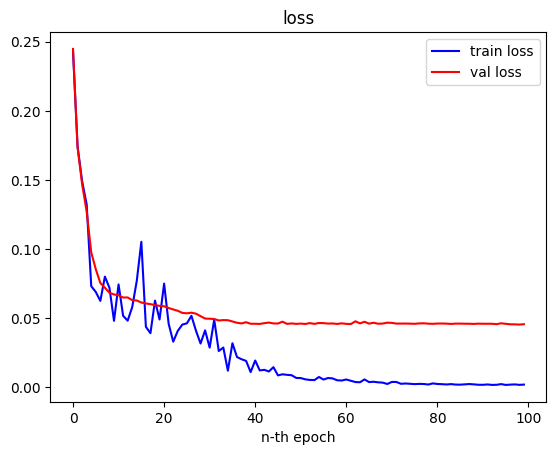

In [6]:
import matplotlib.pyplot as plt  
def draw_result(lst_iter, lst_loss, lst_acc, title):
    plt.plot(lst_iter, lst_loss, '-b', label='train loss')
    plt.plot(lst_iter, lst_acc, '-r', label='val loss')

    plt.xlabel("n-th epoch")
    plt.legend(loc='upper right')
    plt.title(title)

    # save image
    plt.savefig(title+".png",dpi=600)  # should before show method

    # show
    plt.show()
lst_iter = range(0,num_epochs)
draw_result(lst_iter, epoch_loss, epoch_val_loss, "loss")

In [7]:
params = {
    "optimizer": "AdamW",
    "max_epoch": 100

}


# Set our tracking server uri for logging
mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")

# Create a new MLflow Experiment
mlflow.set_experiment("MLflow Quickstart")

# Start an MLflow run
with mlflow.start_run():
    # Log the hyperparameters
    mlflow.log_params(params)

    # Log the loss metric
    mlflow.log_metric("val loss", avg_val_loss)

    # Set a tag that we can use to remind ourselves what this run was for
    mlflow.set_tag("Training Info", "Basic autoencoder model for data")

    # Infer the model signature
    X_train = input_batch.to(device)
    Y_train = auto_cnn(X_train)  
    #signature = infer_signature(X_train.cpu().numpy(),Y_train)

    # Log the model
    model_info = mlflow.sklearn.log_model(
        sk_model=auto_cnn,
        artifact_path="data_model",
        #signature=signature,
        input_example=X_train.cpu().numpy(),
        registered_model_name="tracking-quickstart",
    )

2024/11/26 21:00:28 INFO mlflow.tracking.fluent: Experiment with name 'MLflow Quickstart' does not exist. Creating a new experiment.
2024/11/26 21:00:29 WARNING mlflow.models.signature: Failed to infer the model signature from the input example. Reason: AttributeError("'cnnAutoencoder' object has no attribute 'predict'"). To see the full traceback, set the logging level to DEBUG via `logging.getLogger("mlflow").setLevel(logging.DEBUG)`. To disable automatic signature inference, set `signature` to `False` in your `log_model` or `save_model` call.
2024/11/26 21:00:30 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)

Successful

🏃 View run charming-quail-952 at: http://127.0.0.1:8080/#/experiments/217141786949179948/runs/088b701429054c56b361fcdc6a18aa8c
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/217141786949179948


Created version '1' of model 'tracking-quickstart'.


In [8]:
import numpy as np
import random
from tqdm import tqdm

out_val = []
with torch.no_grad(): 
    for batch, labels in tqdm(val_loader):
        reconstructed_batch = auto_cnn(batch.to(device))
        out_val.append(reconstructed_batch.detach().cpu().numpy())
reconstructed_set = np.vstack(out_val)

100%|█████████████████████████████████████████████| 3/3 [00:00<00:00,  4.30it/s]


In [9]:
# drop the last batch and labels
import matplotlib.pyplot as plt
import matplotlib
from PIL import Image
val_image_set = [v for v, l in list(val_loader)[:-1]]
val_set = np.vstack(val_image_set)

# # Randomly selectes 5 images from the validation set
indxs = random.sample(range(len(reconstructed_set)), 6)


# for i in range(6):
#     original_img = val_set[indxs[i]][0,:]
#     reconstructed_img = reconstructed_set[indxs[i]][0,:]

#     matplotlib.image.imsave("./autoencoder_img_128/ori_"+str(i)+".jpg",original_img)
#     matplotlib.image.imsave("./autoencoder_img_128/recon_"+str(i)+".jpg",reconstructed_img)



# 2.Explore and visualize the latent space with UMAP

In [10]:
# Load the trained model if needed
import torch
auto_cnn = cnnAutoencoder(input_shape=(3, 128, 128), latent_dim=1000)
auto_cnn.load_state_dict(torch.load('cnn_autoencoder_dl.pth'))
auto_cnn.eval()
auto_cnn.to(device)

f_vec = []
with torch.no_grad(): 
    for batch, labels in val_loader:

        batch_f_vec = auto_cnn.encoder(batch.to(device))
        f_vec.append(batch_f_vec.detach().cpu().numpy())
f_vec = np.vstack(f_vec)

f_vec.shape

(40, 1000)

## 2.1 Visualize the experimental dataset

In [11]:
import umap
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

def perform_umap(f_vec, n_neighbors=None, min_dist=None, random_state=None):
    # Perform U-MAP
    if n_neighbors is None and min_dist is None:
        umap_model = umap.UMAP(n_components=2, 
                               random_state=random_state)
    else:
        umap_model = umap.UMAP(n_components=2, 
                               n_neighbors=n_neighbors,
                               min_dist=min_dist,
                               random_state=random_state)
    umap_result = umap_model.fit_transform(f_vec)
    return umap_result

def plot_reduction(reduced_data, original_data, groups=None, category=None, zoom=0.35, savefig=False, outname=None):
    """ This function plots the dimensionally reduced data."""
    
    if 'pca' in category.lower():
        title = 'PCA Results'; xtitle = 'Principal Component 1'; ytitle = 'Principal Component 2'
    elif ('umap' in category.lower()) or ('u-map' in category.lower()):
        title = 'U-Map Results'; xtitle = 'U-Map Dimension 1'; ytitle = 'U-Map Dimension 2'
    else:
        title = 'Dimensionality Reduction Results'; xtitle = 'Reduced Dimension 1'; ytitle = 'Reduced Dimension 2'
    
    plt.figure(figsize=(10, 12))
    plt.rcParams.update({'font.size': 14})
    
    # Plot 2d reduction
    plt.subplot(2,1,1)
    if not groups:
        plt.scatter(reduced_data[:, 0], reduced_data[:, 1], alpha=0.5)
    else:
        # group colors
        #cs = ['y','red', 'green', 'lightcoral','limegreen','rosybrown','aquamarine','royalblue','deepskyblue','navy']
        cs =['red','darkgreen','magenta','greenyellow','pink','cyan']
        #cs = ['y','r', 'g', 'b']
        colors = [cs[i] for i in groups]
        plt.scatter(reduced_data[:, 0], reduced_data[:, 1], alpha=0.5, c=colors)
        #plt.legend(*scatter.legend_elements(),loc="lower left", title="Classes")
        
        
        #plt.legend((cs[0],cs[1],cs[2],cs[3]),['exp', 'generated_fake', 'generated_real', 'train_set'],loc='upper left',ncol=4)
        #plt.legend(loc='upper left',ncol=4)
        
    plt.title(title); plt.xlabel(xtitle); plt.ylabel(ytitle)
    plt.grid(True)

    # Plot 2d reduction with original images
    plt.subplot(2,1,2)
    scatter = plt.scatter(reduced_data[:, 0], reduced_data[:, 1], marker='o', s=30, c='b')
    
    for i in range(len(reduced_data)):

        if original_data[i].shape[0] > 1:
            orig_im = original_data[i][0,:]
        else:
            orig_im = original_data[i]
            
        imagebox = OffsetImage(orig_im, zoom=zoom)  # Adjust the zoom factor as needed
        ab = AnnotationBbox(imagebox, (reduced_data[i, 0], reduced_data[i, 1]), frameon=False)
        plt.gca().add_artist(ab)

    plt.title('Original Images Embedded')
    plt.xlabel(xtitle); plt.ylabel(ytitle); plt.title(title + ' with Original Images')
    plt.grid(True)

    plt.tight_layout()
    if savefig:
        plt.savefig(outname)
    plt.show()
    
    
    pass

In [12]:
print(len(val_set),val_set[0].shape,np.squeeze(val_set).shape)
print(f_vec.shape)

32 (3, 128, 128) (32, 3, 128, 128)
(40, 1000)


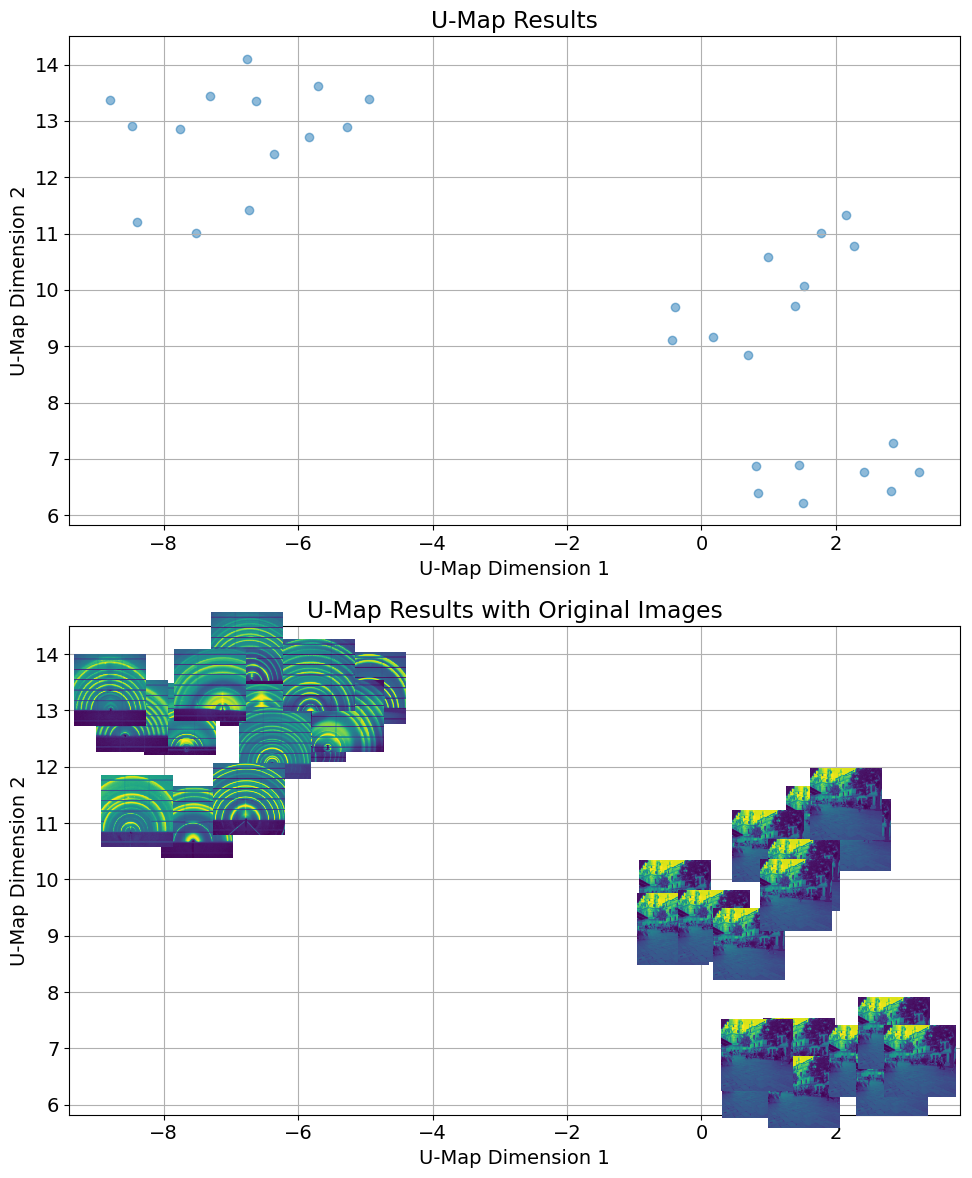

In [13]:
umap_features = perform_umap(f_vec, n_neighbors=5, min_dist=0.5)
umap_features=umap_features[:len(val_set),:]
plot_reduction(umap_features, np.squeeze(val_set), category='umap', zoom=0.4, savefig=True, outname='dynamic_latent.png')